In [ ]:
import pandas as pd

# 1.Data **cleaning**

In [ ]:
df=pd.read_excel("/content/Foodpanda Analysis Dataset (1).xlsx")


In [ ]:
df.head(5)

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
0,C5663,Male,Adult,Peshawar,2024-01-14,O9663,2023-08-23,McDonald's,Burger,Italian,5,1478.27,Cash,38,2025-07-19,238,Active,3,2024-10-14,Cancelled
1,C2831,Male,Adult,Multan,2024-07-07,O6831,2023-08-23,KFC,Burger,Italian,3,956.04,Wallet,24,2024-11-25,81,Active,2,2025-08-21,Delayed
2,C2851,Other,Senior,Multan,2025-06-20,O6851,2023-08-23,Pizza Hut,Fries,Italian,2,882.51,Cash,42,2025-05-10,82,Inactive,3,2024-09-19,Delayed
3,C1694,Female,Senior,Peshawar,2023-09-05,O5694,2023-08-23,Subway,Pizza,Dessert,4,231.30,Card,27,2025-07-24,45,Inactive,2,2025-06-29,Delayed
4,C4339,Other,Senior,Lahore,2023-12-29,O8339,2023-08-24,KFC,Sandwich,Dessert,1,1156.69,Cash,35,2024-12-21,418,Inactive,3,2025-03-06,Cancelled


In [ ]:
df.tail()

,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,quantity,price,payment_method,order_frequency,last_order_date,loyalty_points,churned,rating,rating_date,delivery_status
5995,C6849,Male,Adult,Multan,2024-11-25,O10849,2025-08-22,Pizza Hut,Burger,Italian,4,875.71,Cash,28,2024-11-29,166,Active,5,2024-12-30,Cancelled
5996,C3787,Female,Adult,Islamabad,2025-01-28,O7787,2025-08-22,KFC,Pizza,Italian,5,1118.26,Cash,12,2025-06-08,193,Inactive,3,2025-02-09,Delayed
5997,C2841,Other,Teenager,Islamabad,2023-10-19,O6841,2025-08-22,KFC,Sandwich,Italian,4,1005.83,Card,31,2024-12-30,278,Active,4,2025-03-23,Cancelled
5998,C1624,Male,Adult,Islamabad,2024-06-17,O5624,2025-08-22,KFC,Fries,Fast Food,4,1226.10,Card,37,2024-12-27,55,Inactive,2,2025-03-15,Delivered
5999,C2068,Female,Adult,Multan,2025-03-15,O6068,2025-08-22,Burger King,Fries,Fast Food,3,1131.27,Card,2,2025-06-13,41,Inactive,1,2025-07-15,Delayed


# 2. Find the missing values in each column.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      6000 non-null   object        
 1   gender           6000 non-null   object        
 2   age              6000 non-null   object        
 3   city             6000 non-null   object        
 4   signup_date      6000 non-null   datetime64[ns]
 5   order_id         6000 non-null   object        
 6   order_date       6000 non-null   datetime64[ns]
 7   restaurant_name  6000 non-null   object        
 8   dish_name        6000 non-null   object        
 9   category         6000 non-null   object        
 10  quantity         6000 non-null   int64         
 11  price            6000 non-null   float64       
 12  payment_method   6000 non-null   object        
 13  order_frequency  6000 non-null   int64         
 14  last_order_date  6000 non-null   datetim

In [ ]:
df.isnull().sum()

,0
customer_id,0
gender,0
age,0
city,0
signup_date,0
order_id,0
order_date,0
restaurant_name,0
dish_name,0
category,0


In [ ]:
df.shape

(6000, 20)

In [ ]:
df = df.dropna()

In [ ]:
df = df.drop_duplicates()


In [ ]:
print(df.shape)

(6000, 20)


# 3. Create a new column total_sales = price × quantity. (2)

In [ ]:
df["total_sales"] = df["price"] * df["quantity"]

In [ ]:
print(df[["price", "quantity", "total_sales"]].head())

     price  quantity  total_sales
0  1478.27         5      7391.35
1   956.04         3      2868.12
2   882.51         2      1765.02
3   231.30         4       925.20
4  1156.69         1      1156.69


In [ ]:
print(df.columns)

Index(['customer_id', 'gender', 'age', 'city', 'signup_date', 'order_id',
       'order_date', 'restaurant_name', 'dish_name', 'category', 'quantity',
       'price', 'payment_method', 'order_frequency', 'last_order_date',
       'loyalty_points', 'churned', 'rating', 'rating_date', 'delivery_status',
       'total_sales'],
      dtype='object')


In [ ]:
sales = df.groupby("dish_name")["total_sales"].sum()

# step 4 top 3 **dishes**

In [ ]:
print(sales.sort_values(ascending=False).head(3))

dish_name
Pasta       3078850.36
Sandwich    2966591.11
Pizza       2782227.05
Name: total_sales, dtype: float64


avg rating

5. Write a function rating_label(r) that returns "Good" (rating 4-5), "Average" (rating 3) or "Poor"
*

In [ ]:
avg_rating = df.groupby("category")["rating"].mean()
print(avg_rating)

category
Chinese        3.006678
Continental    2.997523
Dessert        3.050309
Fast Food      2.954992
Italian        2.978964
Name: rating, dtype: float64


Rating Label

In [ ]:
def rating_label(r):
    if r >= 4:
        return "Good"
    elif r == 3:
        return "Average"
    else:
        return "Poor"

In [ ]:
df["rating_label"] = df["rating"].apply(rating_label)

In [ ]:
print(df[["rating", "rating_label"]].head())

   rating rating_label
0       3      Average
1       2         Poor
2       3      Average
3       2         Poor
4       3      Average


# Part C: Visualization + Statistics

# Bar chart of total sales

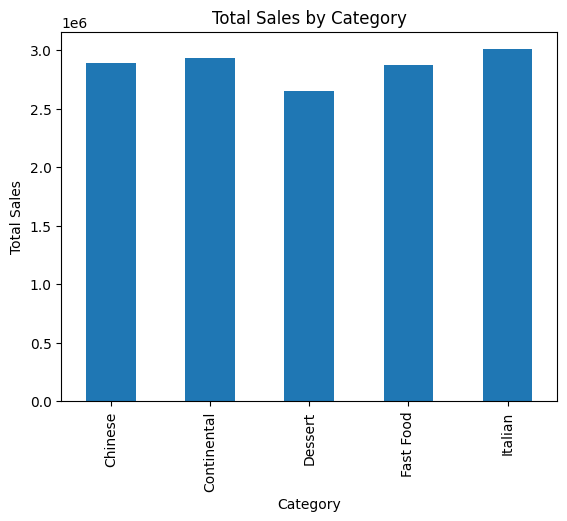

In [ ]:
import matplotlib.pyplot as plt

sales = df.groupby("category")["total_sales"].sum()

sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Histogram draw karna
plt.hist(df['price'], bins=10, color='skyblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Price  Histogram

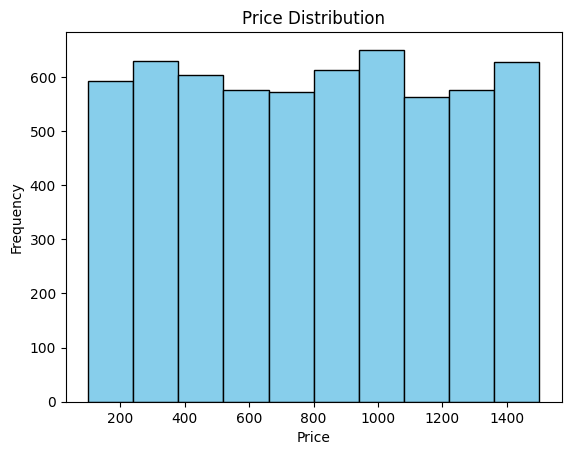

In [ ]:
import matplotlib.pyplot as plt

# Histogram draw karna
plt.hist(df['price'], bins=10, color='skyblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
print(df['total_sales'].mean())
print(df['total_sales'].median())
print(df['total_sales'].std())

2390.6520133333333
1901.5749999999998
1754.874758108934


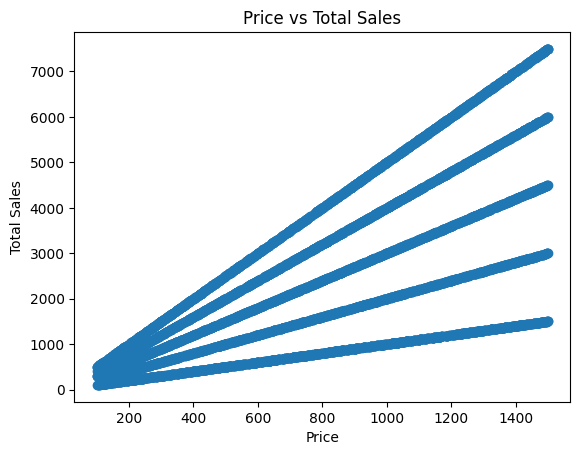

In [ ]:
plt.scatter(df['price'], df['total_sales'])
plt.title('Price vs Total Sales')
plt.xlabel('Price')
plt.ylabel('Total Sales')
plt.show()

# Linear Regression.

In [ ]:
X = df[['price', 'quantity', 'order_frequency']]
y = df['total_sales']

# Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
y_pred = model.predict(X_test)

print(y_pred)

[3176.31541385 2253.41771899 -122.78192297 ... 2773.84141533 1895.26425412
 -148.58523389]


# R2 SCORE

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.8935614191167981


# Our model predicted the total sales quite well, with an R² score of 0.8936.

# This means price, quantity, and order frequency explain most of the changes in total sales

# Only a small part of the sales changes was not explained by our model.